(ch:testing)=
# 1. Hypothesis testing and maximum likelihood

```{admonition} Goals of this chapter
:class: note
After working through this chapter you should be able to

* formulate a null hypothesis, pick a test statistic and compute (or simulate) a $p$-value, and interpret it correctly;
* write down the likelihood of a dataset from a *generative model* and find the maximum-likelihood estimate of the model parameters;
* explain why least-squares fitting is maximum likelihood for Gaussian uncertainties, and what $\chi^2$ per degree of freedom tells you;
* explain how `curve_fit` assigns confidence intervals, and why the default $\chi^2$ rescaling (`absolute_sigma=False`) can go badly wrong for small datasets.

This chapter accompanies Lecture 1 (and the first part of Lecture 6). The running example, the star Blinky observed in photon counts, returns in Chapters {ref}`4 <ch:inference>` and {ref}`6 <ch:mcmc>`.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize
from scipy.optimize import curve_fit

rng = np.random.default_rng(8)    # one random-number generator for the whole notebook
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

## 1.1 Hypothesis testing

Most of this course is about *parameter inference*: we have a model with parameters $\theta$ and we want to know which values of $\theta$ are supported by the data. But before we get there, we recap the older and simpler idea of *hypothesis testing*, because it is everywhere in the literature and because the ingredients (test statistics, simulated datasets) return later.

### The null hypothesis, the test statistic and the $p$-value

A hypothesis test has three ingredients.

1. **A null hypothesis, $H_0$.** This is a statement that can be tested, and typically it is the *less interesting* outcome: "the source is not variable", "the two samples have the same mean", "the slope is zero". It is contrasted with the alternative (or *signal*) hypothesis, $H_1$.

2. **A test statistic (TS).** A statistic is any function that maps a dataset $y = \{y_1, \dots, y_N\}$ onto a single number. Examples: the sample mean, the sample variance, a rank correlation coefficient, a likelihood ratio, or the $\chi^2$ of a fit. A *test* statistic is a statistic chosen such that its value is sensitive to the difference between $H_0$ and $H_1$.

3. **The $p$-value.** This is the probability of obtaining a value of the test statistic *at least as extreme as the one observed*, **if $H_0$ is true**. If the probability distribution of the TS under $H_0$ is known from theory we can compute the $p$-value analytically. If it is not, we can simulate many datasets *assuming $H_0$ is true*, compute the TS for each of them, and count how often the simulated TS is more extreme than the observed one.

The null hypothesis is *rejected* when the $p$-value falls below a significance level (say $p<0.01$) that, ideally, was agreed upon before looking at the data.

```{admonition} Three quiz questions from the lecture
:class: tip
**If $p$ is small, say $p=0.001$, can we (A) reject the null hypothesis, or (B) prove the signal hypothesis?**
A. For a low $p$-value we reject $H_0$. Rejecting $H_0$ does *not* prove $H_1$; some other hypothesis you did not think of may also explain the data.

**If $p$ is large, say $p=0.99$, do we (A) have evidence against the signal hypothesis, or (B) have no evidence against the null hypothesis?**
B. Large $p$-values are of little use: the $p$-value is computed *assuming $H_0$ is true*, so it cannot tell you how probable $H_0$ is. A null hypothesis can never be "accepted", only retained.

**"I want to reject $H_0$ to prove I am right." Is this (A) not how it works, or (B) how we make progress in science?**
Both are correct in their own way. Falsifying hypotheses is how science progresses, but rejecting $H_0$ does not make your favourite alternative true.
```

### Type I and type II errors

Because the decision to reject is made on the basis of a probability, it will sometimes be wrong:

|                | **Retain $H_0$**  | **Reject $H_0$** |
|----------------|-------------------|------------------|
| **$H_0$ true** | correct           | type I error (false positive)  |
| **$H_1$ true** | type II error (false negative) | correct |

The significance level is the type-I error rate you are willing to accept. A $p$-value threshold of $0.05$ means that one in twenty true null hypotheses will be rejected by chance.

### "$n\sigma$" and $p$-values

Astronomers like to translate $p$-values into a number of "sigmas": the $p$-value is set equal to the probability that a standard normal variable exceeds $n$, i.e. $p = 1-\Phi(n)$ (one-sided). Note that there is nothing Gaussian about this; it is only a convention for reporting.

In [2]:
for n_sigma in [1, 2, 3, 4, 5]:
    print(f"{n_sigma} sigma  <->  p = {stats.norm.sf(n_sigma):.1e}   (one-sided)")

1 sigma  <->  p = 1.6e-01   (one-sided)
2 sigma  <->  p = 2.3e-02   (one-sided)
3 sigma  <->  p = 1.3e-03   (one-sided)
4 sigma  <->  p = 3.2e-05   (one-sided)
5 sigma  <->  p = 2.9e-07   (one-sided)


So "$3\sigma$ evidence" means $p \approx 10^{-3}$, and the particle-physics discovery threshold of $5\sigma$ corresponds to $p \approx 3\times 10^{-7}$.

### Don't overdo it

Hypothesis testing gives a structured recipe for making a yes/no decision, and that is also its weakness:

* Any significance threshold ($p=0.05$, $5\sigma$) is arbitrary and leads to wrong incentives. A result can be highly significant and still be tiny and unimportant ("the seductive certainty of significance").
* **The $p$-value is not the probability that $H_0$ is true.** It is the probability of the data (or more extreme data) *given* $H_0$. Confusing the two is the most common misinterpretation in the literature.
* Testing many hypotheses on the same data (many test statistics, many subsamples, many sources) inflates the false-positive rate. This is called the *look-elsewhere effect* or the *multiple testing* problem, and it has to be corrected for.
* Fields where decisions are based on $p<0.05$ (psychology, medicine) have gone through a *replication crisis*: many published "discoveries" turned out to be false positives, due to multiple testing, publication bias (only significant results get published), *p-hacking* (tweaking the analysis until $p<0.05$) and HARKing (Hypothesizing After the Results are Known). Astronomy is not immune.

Before you test, ask yourself: *Do I have a well-defined and well-motivated hypothesis? Do I really need a yes/no decision?* Very often the better question is "how large is the effect?", which is a parameter-inference question with a confidence (or credible) interval as the answer. We will make this switch from testing to inference explicitly in the example below.

(sec:variable-example)=
## 1.2 Worked example: does Blinky blink?

Consider an instrument that counts photons from a star, which we call Blinky, in $N=100$ exposures. The number of counts in each exposure is a Poisson random variable, so if the true count rate is $F_i$ the observed counts are

$$
y_i \sim \mathrm{Poisson}(F_i) .
$$

For a Poisson distribution the variance equals the mean, so the uncertainty of a measurement of $y_i$ counts is $\sigma_{y,i} = \sqrt{y_i}$ (the famous "root-$N$" uncertainty; see the box on the word *uncertainty* below).

We simulate a source whose true flux *does* vary a little from exposure to exposure: the rate $F_i$ is drawn from a normal distribution with mean $1000$ and standard deviation $15$ counts. This intrinsic scatter is small compared to the Poisson noise ($\sqrt{1000} \approx 32$), so it is not obvious by eye. In real life, of course, we would not know the answer.

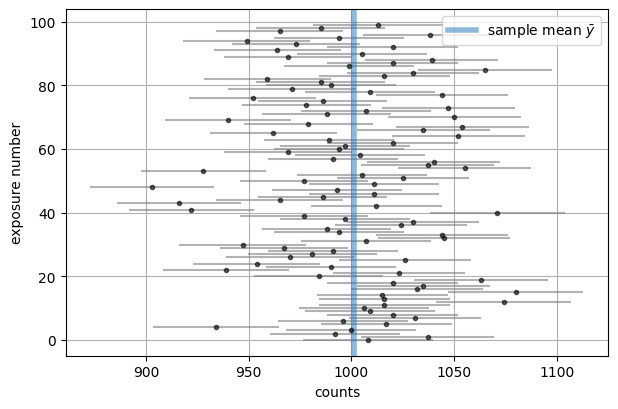

In [3]:
N = 100
mu_true, eps_true = 1000, 15          # mean flux and intrinsic scatter (counts)

F_true = rng.normal(mu_true, eps_true, size=N)   # true flux in each exposure
y = rng.poisson(F_true)                          # observed counts
sigma_y = np.sqrt(y)                             # Poisson uncertainty

fig, ax = plt.subplots()
ax.errorbar(y, np.arange(N), xerr=sigma_y, fmt="ok", ecolor="gray", alpha=0.6, ms=3)
ax.axvline(np.mean(y), lw=4, alpha=0.5, label=r"sample mean $\bar y$")
ax.set_xlabel("counts"); ax.set_ylabel("exposure number"); ax.legend();

```{admonition} Uncertainties, not errors
:class: note
Following Hogg et al. (2010): "They are uncertainties, not errors; if they were errors, we would have corrected them! Data come with uncertainties, which are limitations of knowledge, not mistakes." In these notes $\sigma_{y,i}$ always denotes the (standard-deviation) uncertainty of data point $y_i$.
```

**Step 1: the null hypothesis.** $H_0$: the source is not variable, i.e. all $y_i$ are drawn from the same Poisson distribution with a single rate $\lambda$.

**Step 2: a test statistic.** We try two.

*TS 1: the likelihood of the data under $H_0$.* If $H_0$ holds, the probability of the data is $p(y\,|\,\lambda) = \prod_i \lambda^{y_i} e^{-\lambda}/y_i!$ (Section {ref}`1.3 <sec:likelihood>` explains why we multiply). We do not know $\lambda$, but the best estimate under $H_0$ is the sample mean, $\hat\lambda = \bar y$. A variable source will produce a *lower* likelihood under $H_0$ than a constant source, because some points are far from the mean.

*TS 2: the $\chi^2$ statistic.* If we approximate the Poisson distribution by a normal distribution, $y_i \sim \mathcal{N}(\mu, \sigma_{y,i}^2)$, the null hypothesis of "no intrinsic scatter" predicts

$$
\chi^2 = \sum_{i=1}^{N} \frac{(y_i-\hat\mu)^2}{\sigma_{y,i}^2}
$$ (eq:chi2-const)

with $\hat\mu$ the best-fit constant. The great advantage of $\chi^2$ is that its distribution under $H_0$ is known from theory (the $\chi^2$ distribution with $N-1$ degrees of freedom, since we fitted one parameter), so no simulation is needed.

**Step 3: the $p$-value.**

For TS 1 we do not know the distribution of the statistic, so we simulate: generate many datasets *assuming $H_0$ is true* ($y_i^{\rm sim} \sim \mathrm{Poisson}(\hat\lambda)$), compute the TS for each, and count how often the simulated TS is lower than the observed one.

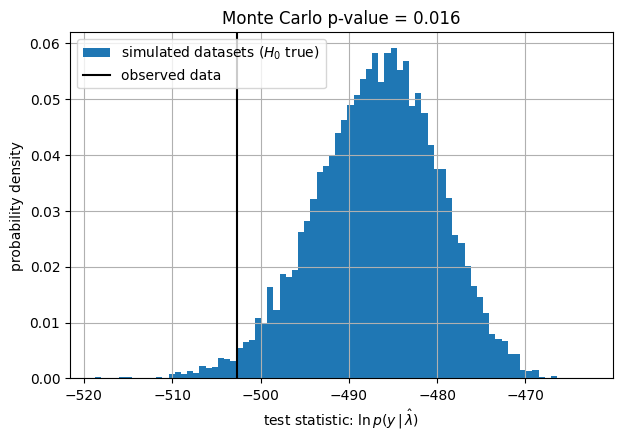

In [4]:
def log_like_poisson(y, lam):
    """log of the Poisson likelihood of counts y for rate lam"""
    return np.sum(stats.poisson.logpmf(y, lam))

lam_hat = np.mean(y)
TS_data = log_like_poisson(y, lam_hat)

n_sim = 10_000
TS_sim = np.zeros(n_sim)
for i in range(n_sim):
    y_sim = rng.poisson(lam_hat, size=N)                 # a dataset if H0 is true
    TS_sim[i] = log_like_poisson(y_sim, np.mean(y_sim))  # same statistic, same estimator

p_value_MC = np.mean(TS_sim < TS_data)

fig, ax = plt.subplots()
ax.hist(TS_sim, bins=80, density=True, label=r"simulated datasets ($H_0$ true)")
ax.axvline(TS_data, color="k", label="observed data")
ax.set_xlabel(r"test statistic: $\ln p(y\,|\,\hat\lambda)$"); ax.set_ylabel("probability density")
ax.set_title(f"Monte Carlo p-value = {p_value_MC:.3f}"); ax.legend();

For TS 2 we use the known $\chi^2$ distribution. The best-fit constant for data with unequal uncertainties is the *inverse-variance weighted mean*, $\hat\mu = \sum_i y_i/\sigma_{y,i}^2 \big/ \sum_i 1/\sigma_{y,i}^2$ (it is the maximum-likelihood estimate; you derive it in the tutorial exercises), and the $p$-value is the probability of finding a $\chi^2$ larger than observed, $P(\chi^2_{N-1} > \chi^2_{\rm obs})$, which `scipy` provides as the *survival function* `sf`.

chi2 = 131.8 for 99 degrees of freedom; chi2/dof = 1.33
p-value from the chi2 distribution: 0.015


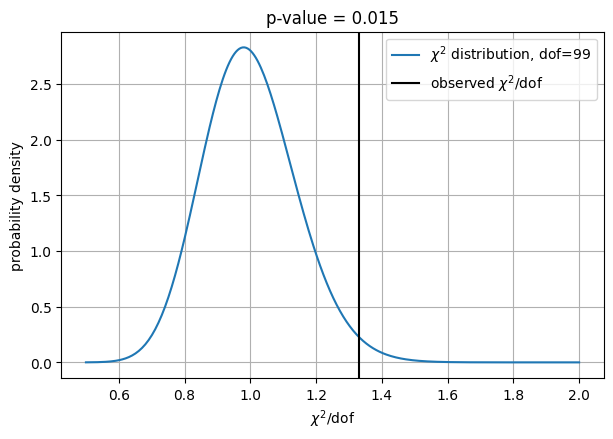

In [5]:
def chi2_stat(mu, y, sigma_y):
    return np.sum((y - mu)**2 / sigma_y**2)

w = 1 / sigma_y**2
mu_hat = np.sum(w * y) / np.sum(w)         # inverse-variance weighted mean
chi2_obs = chi2_stat(mu_hat, y, sigma_y)
dof = N - 1                                # one fitted parameter
p_value_chi2 = stats.chi2.sf(chi2_obs, dof)

print(f"chi2 = {chi2_obs:.1f} for {dof} degrees of freedom; chi2/dof = {chi2_obs/dof:.2f}")
print(f"p-value from the chi2 distribution: {p_value_chi2:.3f}")

xx = np.linspace(0.5, 2.0, 300) * dof
fig, ax = plt.subplots()
ax.plot(xx/dof, stats.chi2.pdf(xx, dof) * dof, label=rf"$\chi^2$ distribution, dof={dof}")
ax.axvline(chi2_obs/dof, color="k", label=r"observed $\chi^2/$dof")
ax.set_xlabel(r"$\chi^2/$dof"); ax.set_ylabel("probability density")
ax.set_title(f"p-value = {p_value_chi2:.3f}"); ax.legend();

Both test statistics agree: the data are unlikely under $H_0$, with $p$ of order $10^{-2}$, which we may call "$2\sigma$ evidence" for variability. That is worth reporting and worth following up, but it is not a discovery. Notice also what the test does *not* tell us: how variable the source is. In Chapter {ref}`4 <ch:inference>` we replace the yes/no question by a parameter, the intrinsic scatter $\epsilon$, and measure it.

```{admonition} One-sided or two-sided?
:class: note
We asked for the probability that the simulated TS is *lower* than the observed one, because variability can only lower the likelihood under $H_0$ (and only increase $\chi^2$). This is a *one-sided* test. If deviations in both directions would count as evidence against $H_0$ (e.g. testing whether a mean differs from zero), you use a two-sided test and the $p$-value doubles.
```

(sec:likelihood)=
## 1.3 Parameter inference and the likelihood

### Notation

* The data are $y = \{y_1, \dots, y_N\}$; when we need the "independent variable" (time, position, wavelength) we write $x_i$ for it, and $\sigma_{y,i}$ for the uncertainty of $y_i$. The $x_i$ are assumed to have no uncertainty: they are part of the experimental design.
* The model parameters are $\theta = \{\theta_1, \dots, \theta_k\}$. The model prediction for data point $i$ is $m(x_i, \theta)$.
* The true (unknown) parameter values are $\theta^*$; an estimate from the data is $\hat\theta$.

The question we would like to ask is: *given the data, which value of $\theta^*$ is most probable?* In the frequentist framework this question is not allowed: $\theta^*$ is a fixed number, not a random variable, so we cannot make probabilistic statements about it (Bayesian statistics, from Chapter {ref}`3 <ch:foundations>` on, will allow exactly this). The question we *can* ask is the reverse one: *given a parameter value $\theta$, how probable are the data we observed?*

### The generative model

To answer that question we need a **generative model**: a parameterized, quantitative description of a statistical process that could reasonably have generated the data we have (Hogg et al. 2010). In practice this means we state that the data are drawn from some probability density function (PDF) that depends on $\theta$:

$$
y_i \sim f_\theta ,
$$

read as "$y_i$ is drawn from $f_\theta$". Two remarks. First, "the data are drawn from *some* PDF" is always true. Second, that this PDF is the one described by our model with parameters $\theta^*$ is an *assumption*; it is exactly the assumption we are investigating with the data, and if the model is wrong, all bets are off. The strength of a generative model is that it can be *simulated*: we can draw fake datasets from it, which is precisely what we did for the Monte Carlo $p$-value above.

The simplest and most common generative model is Gaussian noise: each data point scatters around the model prediction by a Gaussian random offset of known width,

$$
p(y_i\,|\,x_i, \sigma_{y,i}, \theta) = \frac{1}{\sqrt{2\pi\sigma_{y,i}^2}} \exp\left(-\frac{[y_i - m(x_i,\theta)]^2}{2\sigma_{y,i}^2}\right) .
$$ (eq:gauss-generative)

### The likelihood function

If the data points are drawn *independently*, the probability of the whole dataset is the product of the probabilities of the individual points (Chapter {ref}`3 <ch:foundations>` shows why). This product, viewed as a function of the parameters, is the **likelihood**:

$$
\mathcal{L}(\theta) \equiv p(y\,|\,\theta) = \prod_{i=1}^{N} p(y_i\,|\,\theta) .
$$ (eq:likelihood)

Because products of many small numbers are numerically unpleasant, and because derivatives of sums are easier than derivatives of products, we almost always work with the **log-likelihood** $\ln \mathcal{L}(\theta) = \sum_i \ln p(y_i\,|\,\theta)$.

### The maximum-likelihood estimator

The **maximum-likelihood estimate** (MLE) is the parameter value at which the observed data are most probable:

$$
\hat\theta = \arg\max_\theta \mathcal{L}(\theta) = \arg\max_\theta \ln\mathcal{L}(\theta) .
$$ (eq:mle)

(The maximum of a function and of its logarithm are at the same place.) Analytically, we find it by setting all partial derivatives $\partial \ln\mathcal{L}/\partial\theta_j$ to zero and solving; numerically, we hand $-\ln\mathcal{L}$ to a minimizer such as `scipy.optimize.minimize`.

Why maximum likelihood? Fisher, who introduced the method, showed that (for large $N$) no other estimator has a smaller variance, so the MLE extracts the maximum information from the data; Laplace would have called it common sense (his dictum: probability theory is "nothing but common sense reduced to calculation"). The caveat is that the MLE is only as good as the model: if the assumed PDF is wrong (say, heavy tails where you assumed a Gaussian), the estimate can be badly off. During the 2007–2008 financial crisis, banks reported daily losses that their risk models rated as "25-standard-deviation events, several days in a row"; that was not bad luck, it was a wrong model.

### Example: analytical versus numerical MLE

Take the counts from Section {ref}`1.2 <sec:variable-example>` and, ignoring the Poisson nature of the data for a moment, model them as $y_i \sim \mathcal{N}(\mu, \sigma^2)$ with two unknown parameters. The log-likelihood is

$$
\ln\mathcal{L}(\mu,\sigma) = -\frac{N}{2}\ln(2\pi) - N\ln\sigma - \frac{1}{2\sigma^2}\sum_{i=1}^{N}(y_i-\mu)^2 .
$$ (eq:loglike-gauss)

Setting $\partial\ln\mathcal{L}/\partial\mu = 0$ gives $\hat\mu = \bar y$ (the sample mean), and $\partial\ln\mathcal{L}/\partial\sigma = 0$ gives $\hat\sigma^2 = \frac{1}{N}\sum_i (y_i-\hat\mu)^2$. Let's check this against a numerical maximization.

In [6]:
def neg_log_like(theta, y):
    mu, sigma = theta
    if sigma <= 0:
        return np.inf
    return 0.5*len(y)*np.log(2*np.pi) + len(y)*np.log(sigma) + np.sum((y - mu)**2) / (2*sigma**2)

# analytical
mu_ana, sigma_ana = np.mean(y), np.sqrt(np.mean((y - np.mean(y))**2))

# numerical
res = optimize.minimize(neg_log_like, x0=[900, 10], args=(y,), method="Nelder-Mead")
mu_num, sigma_num = res.x

print(f"analytical: mu = {mu_ana:.3f}, sigma = {sigma_ana:.3f}")
print(f"numerical : mu = {mu_num:.3f}, sigma = {sigma_num:.3f}")

analytical: mu = 1001.320, sigma = 36.119
numerical : mu = 1001.320, sigma = 36.119


Note that $\hat\sigma \approx 36$ counts is larger than the Poisson noise $\sqrt{1000}\approx 32$: the extra scatter is the variability we detected in Section {ref}`1.2 <sec:variable-example>`. In Chapter {ref}`4 <ch:inference>` we will separate the two contributions explicitly.

## 1.4 Least squares is maximum likelihood (for Gaussian uncertainties)

Now let the model depend on $x$: $m(x,\theta)$, e.g. a straight line $m(x, \theta) = a + b x$ with $\theta=(a,b)$, and let every point have its own known uncertainty $\sigma_{y,i}$. With the Gaussian generative model of Eq. {eq}`eq:gauss-generative` the log-likelihood is

$$
\ln\mathcal{L}(\theta) = K - \frac{1}{2}\sum_{i=1}^{N}\frac{[y_i - m(x_i,\theta)]^2}{\sigma_{y,i}^2} = K - \frac{1}{2}\chi^2(\theta) ,
$$ (eq:loglike-chi2)

where $K = -\sum_i \ln\sqrt{2\pi\sigma_{y,i}^2}$ does not depend on $\theta$, and

$$
\chi^2(\theta) = \sum_{i=1}^{N}\frac{[y_i - m(x_i,\theta)]^2}{\sigma_{y,i}^2} .
$$ (eq:chi2)

Maximizing the likelihood is therefore *identical* to minimizing $\chi^2$: **weighted least-squares fitting is maximum likelihood for independent Gaussian uncertainties of known size.**

```{admonition} Proof (from the board in Lecture 1)
:class: note
Start from the generative model of Eq. {eq}`eq:gauss-generative` and the likelihood of Eq. {eq}`eq:likelihood`:

$$
\mathcal{L}(\theta) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi\sigma_{y,i}^2}} \exp\left(-\frac{[y_i - m(x_i,\theta)]^2}{2\sigma_{y,i}^2}\right) .
$$

Take the logarithm; the product becomes a sum and the exponential disappears:

$$
\ln\mathcal{L}(\theta) = \sum_{i=1}^{N}\left[-\tfrac12\ln\left(2\pi\sigma_{y,i}^2\right)\right] - \sum_{i=1}^{N}\frac{[y_i - m(x_i,\theta)]^2}{2\sigma_{y,i}^2} = K - \tfrac12\chi^2(\theta) .
$$

The first sum, $K$, contains only the *known* uncertainties and not the parameters, so it is a constant. Hence $\partial\ln\mathcal{L}/\partial\theta_j = -\tfrac12\,\partial\chi^2/\partial\theta_j$ for every parameter, and the maximum of $\ln\mathcal{L}$ is at the minimum of $\chi^2$. For the simplest case, a constant model $m(x_i,\theta) = \mu$ with equal uncertainties, $\partial\chi^2/\partial\mu = -2\sum_i(y_i-\mu)/\sigma^2 = 0$ gives $\hat\mu = \bar y$, the sample mean; with unequal uncertainties the same step gives the inverse-variance weighted mean (tutorial exercise).

Note what the proof needs: Gaussian scatter, *known* $\sigma_{y,i}$ (otherwise $K$ is not a constant; see Chapter 4), and independent data points (otherwise there is no product).
```

If the uncertainties are unknown, or the same for all points, the weights drop out and we minimize the plain sum of squared residuals. Under these conditions there is nothing wrong with least squares; Hogg et al. (2010) call it a "miracle" that the Gaussian assumption turns the optimum into a linear function of the data (for linear models it can be written as a matrix expression, their Eq. 5).

The flip side: if the uncertainties are *not* Gaussian (Poisson counts with few photons, outliers, asymmetric uncertainties), least squares is no longer optimal, while maximum likelihood still works: just write down the correct likelihood. And least squares gives you a best fit but by itself does not tell you whether the model is adequate or whether an extra parameter is warranted; for that we need the tools of Chapter {ref}`2 <ch:model-selection>`.

### $\chi^2$ as a statistic: degrees of freedom and goodness of fit

$\chi^2$ is itself a statistic, and for Gaussian data its distribution is known: if the model is correct and the $\sigma_{y,i}$ are correct, the minimum $\chi^2$ follows a $\chi^2$ distribution with

$$
\mathrm{dof} = N - k
$$

degrees of freedom, where $k$ is the number of fitted parameters. The expectation value of a $\chi^2$ distribution equals its number of degrees of freedom, so a good fit has

$$
\chi^2/\mathrm{dof} \approx 1 .
$$

Much larger values mean the model is missing something or the uncertainties are underestimated; much smaller values mean the uncertainties are overestimated. This is exactly the "goodness-of-fit" test we used as TS 2 in Section {ref}`1.2 <sec:variable-example>`.

```{admonition} Gedankenexperiment: two data points
:class: tip
You have two data points and want to fit a line. Can you? What is $\chi^2$ and what is the dof? Can you estimate the uncertainty on the slope if the uncertainties on the data are unknown? And if they are known? What changes with three points?

*Answers:* Yes, a line through two points always exists, so $\chi^2 = 0$ and dof $= 0$. With unknown uncertainties there is no information about the scatter at all, so no uncertainty on the slope can be estimated. With known $\sigma_{y,i}$ the uncertainty on the slope follows from propagating the two uncertainties. With three points, dof $=1$ and the residual of the third point gives a (very noisy) handle on the scatter.
```

### Example: fitting a straight line to real-ish data

We use the dataset of Hogg et al. (2010), Table 1, and follow their Exercise 1: fit points 5–20 (we deal with points 1–4, the outliers, in Chapter {ref}`7 <ch:advanced>`). The uncertainties $\sigma_{y,i}$ are given and we believe them, so we tell `curve_fit` so with `absolute_sigma=True`.

intercept a =   34.0 +/- 18.2
slope     b =  2.240 +/- 0.108
chi2/dof = 18.7/14 = 1.33;  goodness-of-fit p = 0.18


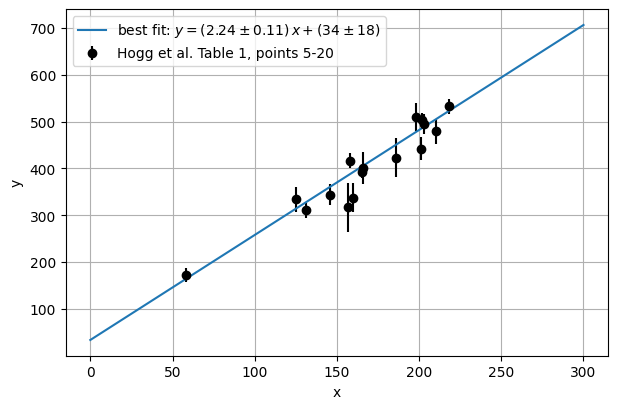

In [7]:
hogg = np.genfromtxt("data/hogg_table1.csv", delimiter=",", names=True)
clean = hogg["id"] >= 5
x_h, y_h, sy_h = hogg["x"][clean], hogg["y"][clean], hogg["sigma_y"][clean]

def line(x, a, b):
    return a + b * x

popt, pcov = curve_fit(line, x_h, y_h, sigma=sy_h, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))
chi2_min = chi2_stat(line(x_h, *popt), y_h, sy_h)
dof = len(y_h) - 2

print(f"intercept a = {popt[0]:6.1f} +/- {perr[0]:.1f}")
print(f"slope     b = {popt[1]:6.3f} +/- {perr[1]:.3f}")
print(f"chi2/dof = {chi2_min:.1f}/{dof} = {chi2_min/dof:.2f};  goodness-of-fit p = {stats.chi2.sf(chi2_min, dof):.2f}")

fig, ax = plt.subplots()
ax.errorbar(x_h, y_h, sy_h, fmt="ok", label="Hogg et al. Table 1, points 5-20")
xx = np.linspace(0, 300, 10)
ax.plot(xx, line(xx, *popt), label=fr"best fit: $y = ({popt[1]:.2f}\pm{perr[1]:.2f})\,x + ({popt[0]:.0f}\pm{perr[0]:.0f})$")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend();

This reproduces Figure 1 of Hogg et al. The $\chi^2$ per degree of freedom is close to one, so the straight line with the quoted uncertainties is an adequate description of these 16 points.

## 1.5 Confidence intervals from least squares

### What is a confidence interval?

A best-fit value without an uncertainty is useless. The frequentist way to express the uncertainty is a **confidence interval**: an interval $(\hat\theta_{\rm l}, \hat\theta_{\rm u})$ constructed from the data such that, if we repeated the experiment many times, a fraction $\gamma$ (the *confidence level*) of the intervals would contain the true value $\theta^*$. The customary choice is $\gamma = 0.683$ ("$\pm1\sigma$"), sometimes $0.95$. Note the careful wording: the interval is the random thing, not $\theta^*$. The Bayesian *credible interval* (Chapter {ref}`4 <ch:inference>`) is the more intuitive statement "with probability $\gamma$ the parameter lies in this interval".

If the estimator is approximately normally distributed around the true value, $\hat\theta \sim \mathcal{N}(\theta^*, \sigma_\theta^2)$, then $\hat\theta \pm \sigma_\theta$ is a 68.3% confidence interval and $\hat\theta \pm 1.96\,\sigma_\theta$ a 95% interval. The number $\sigma_\theta$ is called the *standard error* of the parameter. So the whole problem is to find $\sigma_\theta$.

### How `curve_fit` assigns the uncertainties

Least-squares codes return a *covariance matrix* of the parameters, with the variances $\sigma_\theta^2$ on the diagonal. It is obtained from the curvature of $\chi^2$ around its minimum: for a linear model and known Gaussian uncertainties, the covariance is $[A^\top C^{-1} A]^{-1}$ with $A$ the design matrix and $C$ the data covariance (Hogg et al., Eq. 5); for a non-linear model the same expression is used with the model linearized around the best fit. The proofs are not exam material; the two practical points are:

1. **`absolute_sigma=True`**: the $\sigma_{y,i}$ you pass in are taken at face value and the covariance follows from them. This is what we did above, and what you should do if you trust your uncertainties.

2. **`absolute_sigma=False` (the default!)**: the $\sigma_{y,i}$ are treated as *relative* weights only, and the covariance is rescaled by $\chi^2_{\min}/\mathrm{dof}$, i.e. the code *forces* $\chi^2/\mathrm{dof}=1$. This is the only option if you have no uncertainties at all (then `curve_fit` assumes $\sigma_{y,i}=1$ and estimates the scatter from the residuals), and it looks like a harmless "correction" when your uncertainties are slightly off. But it makes the size of your confidence interval depend on the *noise in a single realization of $\chi^2$*, and for small $N$ that noise is enormous.

The rest of this section is a simulation to show how large the effect is. This is the "multiverse" notebook of the first werkcollege.

### The multiverse: simulate many datasets

When in doubt, run a simulation. We take a linear model with known true parameters, simulate a dataset with *perfectly known* Gaussian uncertainties, fit it, and repeat 10,000 times. From the spread of the best-fit values we know what the *correct* standard error is, and we can compare it with what `curve_fit` reports for each individual dataset.

In [8]:
a_true, b_true = 2.0, 1.0
xmin, xmax = 0.1, 10

def sim_data(x, sigma=1.0):
    """simulate data from the line, with a fixed Gaussian uncertainty per point"""
    y_true = line(x, a_true, b_true)
    y_unc = np.full_like(x, sigma)
    return rng.normal(y_true, y_unc), y_unc

def multiverse(n_points, n_sims=10_000):
    x_data = np.linspace(xmin, xmax, n_points)   # the x positions are fixed in every universe
    b_fit, b_err, chi2_vals = np.zeros(n_sims), np.zeros(n_sims), np.zeros(n_sims)
    for i in range(n_sims):
        y_sim, y_unc = sim_data(x_data)
        popt, pcov = curve_fit(line, x_data, y_sim, sigma=y_unc, absolute_sigma=False)  # the default
        b_fit[i], b_err[i] = popt[1], np.sqrt(pcov[1, 1])
        chi2_vals[i] = chi2_stat(line(x_data, *popt), y_sim, y_unc)
    # the correct standard error: uses the true uncertainties, and is the same for every universe
    _, pcov_true = curve_fit(line, x_data, y_sim, sigma=y_unc, absolute_sigma=True)
    return b_fit, b_err, chi2_vals, np.sqrt(pcov_true[1, 1])

N= 3: reported sigma_b is >50% too large in 13.7% of the universes, and >50% too small in 49.2%


N=10: reported sigma_b is >50% too large in  2.1% of the universes, and >50% too small in 10.2%


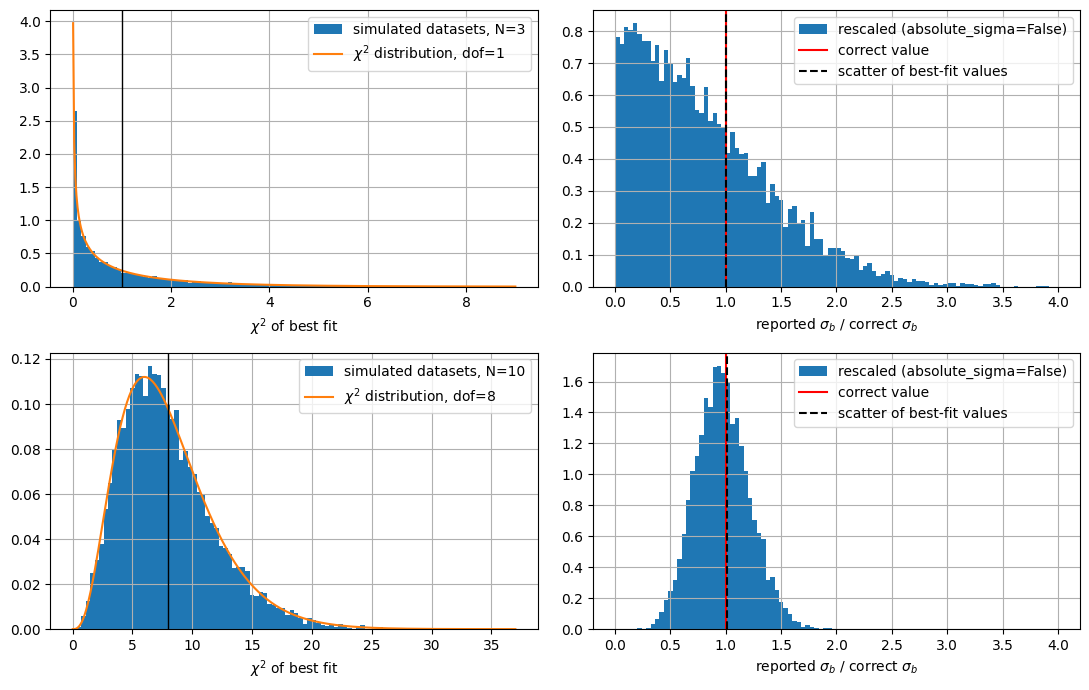

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for row, n_points in zip(axs, [3, 10]):
    b_fit, b_err, chi2_vals, sigma_b_correct = multiverse(n_points)
    dof = n_points - 2

    # left: the distribution of chi2 (compare to theory)
    ax = row[0]
    ax.hist(chi2_vals, bins=100, density=True, range=(0, 4*dof+5), label=f"simulated datasets, N={n_points}")
    cc = np.linspace(0.01, 4*dof+5, 400)
    ax.plot(cc, stats.chi2.pdf(cc, dof), label=fr"$\chi^2$ distribution, dof={dof}")
    ax.axvline(dof, color="k", lw=1)
    ax.set_xlabel(r"$\chi^2$ of best fit"); ax.legend()

    # right: the standard error reported by curve_fit, versus the correct value
    ax = row[1]
    ax.hist(b_err / sigma_b_correct, bins=100, range=(0, 4), density=True, label="rescaled (absolute_sigma=False)")
    ax.axvline(1, color="r", label="correct value")
    ax.axvline(np.std(b_fit) / sigma_b_correct, color="k", ls="--", label="scatter of best-fit values")
    ax.set_xlabel(r"reported $\sigma_b$ / correct $\sigma_b$"); ax.legend()

    too_large = np.mean(b_err / sigma_b_correct > 1.5) * 100
    too_small = np.mean(b_err / sigma_b_correct < 1/1.5) * 100
    print(f"N={n_points:2d}: reported sigma_b is >50% too large in {too_large:4.1f}% of the universes, "
          f"and >50% too small in {too_small:4.1f}%")
plt.tight_layout()

What do we learn?

* The best-fit slopes scatter around the truth with a standard deviation that is exactly the `absolute_sigma=True` value (dashed line at 1). That is the confidence interval we want.
* For $N=3$ (one degree of freedom) the $\chi^2$ of a single dataset is anywhere between 0 and 4, so the rescaled standard error is too small by more than 50% in roughly half of the universes and too large by 50% in a good fraction of the rest. With `absolute_sigma=False` your "$\pm1\sigma$" is essentially a random number.
* For $N=10$ the distribution narrows around the correct value, but a spread of tens of percent remains. Only for $N \gg k$ does the rescaling become harmless.

The lesson: **if you know your uncertainties, use them (`absolute_sigma=True`).** If you do not, the $\chi^2$ rescaling is a crude fix that only works for large $N$; better options are the bootstrap (Chapter {ref}`2 <ch:model-selection>`) or, best of all, making the unknown extra scatter a parameter of your statistical model and inferring it from the data (Chapter {ref}`4 <ch:inference>`).

## 1.6 Test yourself

These are pen-and-paper questions at the level of the exam. Try them before opening the answers.

````{admonition} Q1. Is Taylor variable? (exam 2025)
:class: tip
We have 26 flux measurements $y_i$ of the star Taylor, obtained over a single night, each with its own uncertainty $\sigma_{y,i}$. We want to discover intra-night variability.

1. Write down the null hypothesis.
2. A possible test statistic is the sample variance of the 26 measurements. Explain how this test statistic can be used to obtain statistical evidence for variability.
3. Explain how the $\chi^2$ statistic can be used to obtain evidence for variability. Sketch the $\chi^2$ distribution to illustrate your answer.

```{admonition} Answer
:class: dropdown
1. $H_0$: the flux of Taylor is constant during the night; all $y_i$ are drawn from the same distribution with mean $\mu$ and the scatter is due to measurement uncertainty only.
2. Under $H_0$ we can simulate datasets: draw $y_i^{\rm sim} \sim \mathcal{N}(\hat\mu, \sigma_{y,i}^2)$ with $\hat\mu$ the (weighted) mean of the data. Compute the sample variance of each simulated dataset. The $p$-value is the fraction of simulations with a sample variance *larger* than the observed one. A small $p$ (say $<0.01$) is evidence for variability. (The sample variance does not have a simple known distribution when the $\sigma_{y,i}$ differ, hence the simulation.)
3. Compute $\chi^2 = \sum_i (y_i-\hat\mu)^2/\sigma_{y,i}^2$. If $H_0$ is true this follows a $\chi^2$ distribution with $26-1=25$ degrees of freedom: a skewed distribution peaking near 23, with mean 25 and a tail to the right. The $p$-value is the area under this distribution to the right of the observed $\chi^2$; an observed $\chi^2/\mathrm{dof}$ well above one is evidence for variability (or for underestimated uncertainties).
```
````

````{admonition} Q2. Counting dark matter (exam 2023)
:class: tip
An experiment counts particles from dark-matter decay; the probability of $y$ counts when $\lambda$ are expected is $p(y\,|\,\lambda) = \lambda^y e^{-\lambda}/y!$. The detector also registers background counts, with an expectation value of $\lambda_{\rm bg} = 0.5$ in our 10-second exposure. We observe 2 counts.

1. Formulate a null hypothesis.
2. Estimate the $p$-value of the null hypothesis (hint: evaluate the Poisson probability for $y = 0, 1, 2, 3, \dots$).
3. How would you report the result? Choose from (A) "we find no evidence for dark-matter decay", (B) "we find evidence for dark-matter decay at the $2\sigma$ level", (C) "we find a significant detection of dark-matter decay ($p < 10^{-6}$)", and motivate your choice.

```{admonition} Answer
:class: dropdown
1. $H_0$: the observed counts are due to the background alone, i.e. $y \sim \mathrm{Poisson}(0.5)$.
2. The $p$-value is the probability of observing 2 *or more* counts if $H_0$ is true: $P(y\geq2\,|\,\lambda=0.5) = 1 - P(0) - P(1) = 1 - e^{-0.5}(1 + 0.5) \approx 0.09$ (or sum the terms: $P(2) = 0.076$, $P(3) = 0.013$, $P(4) = 0.002$, ...).
3. Not C: $p\approx0.1$ is nowhere near $10^{-6}$; if you expect 0.5 counts you will see 2 by chance one time in ten. B is defensible ("weak evidence": $p \approx 0.1$ corresponds to $1.3\sigma$ one-sided, so even "$2\sigma$" is generous), and so is A if you had fixed a threshold such as $p<0.05$ beforehand. Whatever you choose, quote the $p$-value.
```
````

````{admonition} Q3. Three ways to get an uncertainty (practice exam)
:class: tip
You are given data $y$ *without* reported uncertainties, at known positions $x$, and you want to measure the slope $b$ of $y = a + b x$. List three different ways to infer the uncertainty on $b$, in one or two sentences each, and name one underlying assumption of each.

```{admonition} Answer
:class: dropdown
1. *Least squares with $\chi^2$ rescaling:* set $\sigma_{y,i}=1$, minimize $\chi^2$, and rescale the covariance such that $\chi^2/(N-2)=1$ (this is `absolute_sigma=False`). Assumes Gaussian scatter that is the same for all points, and $N$ large enough for the rescaling to be stable.
2. *Bootstrap* (Chapter 2): refit many resampled versions of the data (drawn with replacement); the spread of the best-fit slopes gives the interval. Assumes the sample is representative of the population (few other assumptions).
3. *Model the scatter* (Chapter 4): include an extra variance $\epsilon^2$ in the likelihood, use flat priors with $\epsilon>0$, and obtain the posterior of $b$ by MCMC or a grid search, marginalizing over $\epsilon$. Assumes the scatter is Gaussian and the priors are reasonable.
```
````

## Sources and further reading

* Hogg, Bovy & Lang (2010), *Data analysis recipes: Fitting a model to data*, [arXiv:1008.4686](https://arxiv.org/abs/1008.4686), Sections 1–2. The mandatory reading for this course.
* Gelman et al. (2013), *Bayesian Data Analysis* (3rd ed.), [free PDF](https://sites.stat.columbia.edu/gelman/book/BDA3.pdf), Chapter 1 for the setup of statistical inference.
* Wasserman (2004), *All of Statistics*, Springer, Chapters 9–10 (maximum likelihood, hypothesis testing).
* VanderPlas (2014), *Frequentism and Bayesianism: a practical introduction* ([blog post](http://jakevdp.github.io/blog/2014/03/11/frequentism-and-bayesianism-a-practical-intro/)), the origin of the Blinky example.
* Ioannidis (2005), *Why most published research findings are false*, PLoS Medicine 2, e124, [doi:10.1371/journal.pmed.0020124](https://doi.org/10.1371/journal.pmed.0020124), on the replication crisis.